In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Carregamento do dataset
file = 'NDT_clean.csv'
file_path = os.path.join("NDT dataset", file)
df_clean = pd.read_csv(file_path)

# Conversão de timestamp
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['data'] = df_clean['timestamp'].dt.date

Total de medições: 214618
Total de clientes distintos: 16
Total de servidores distintos: 6
Total de pares cliente-servidor distintos: 59


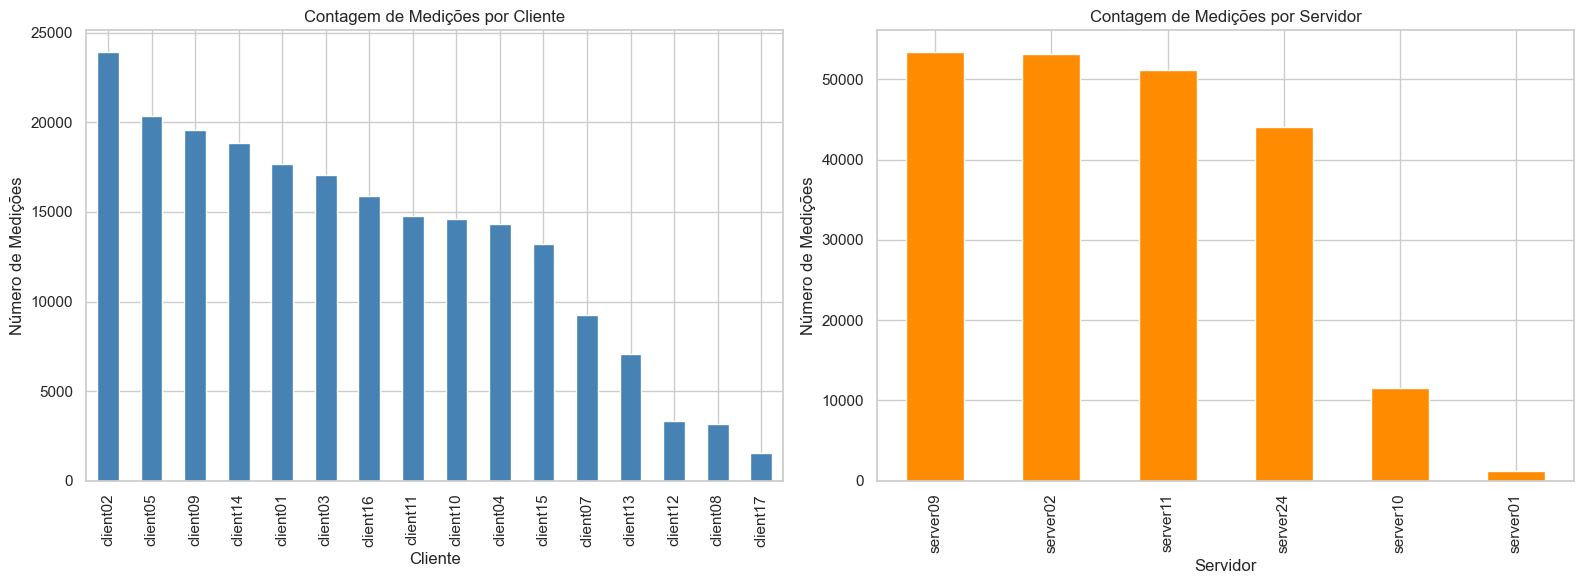

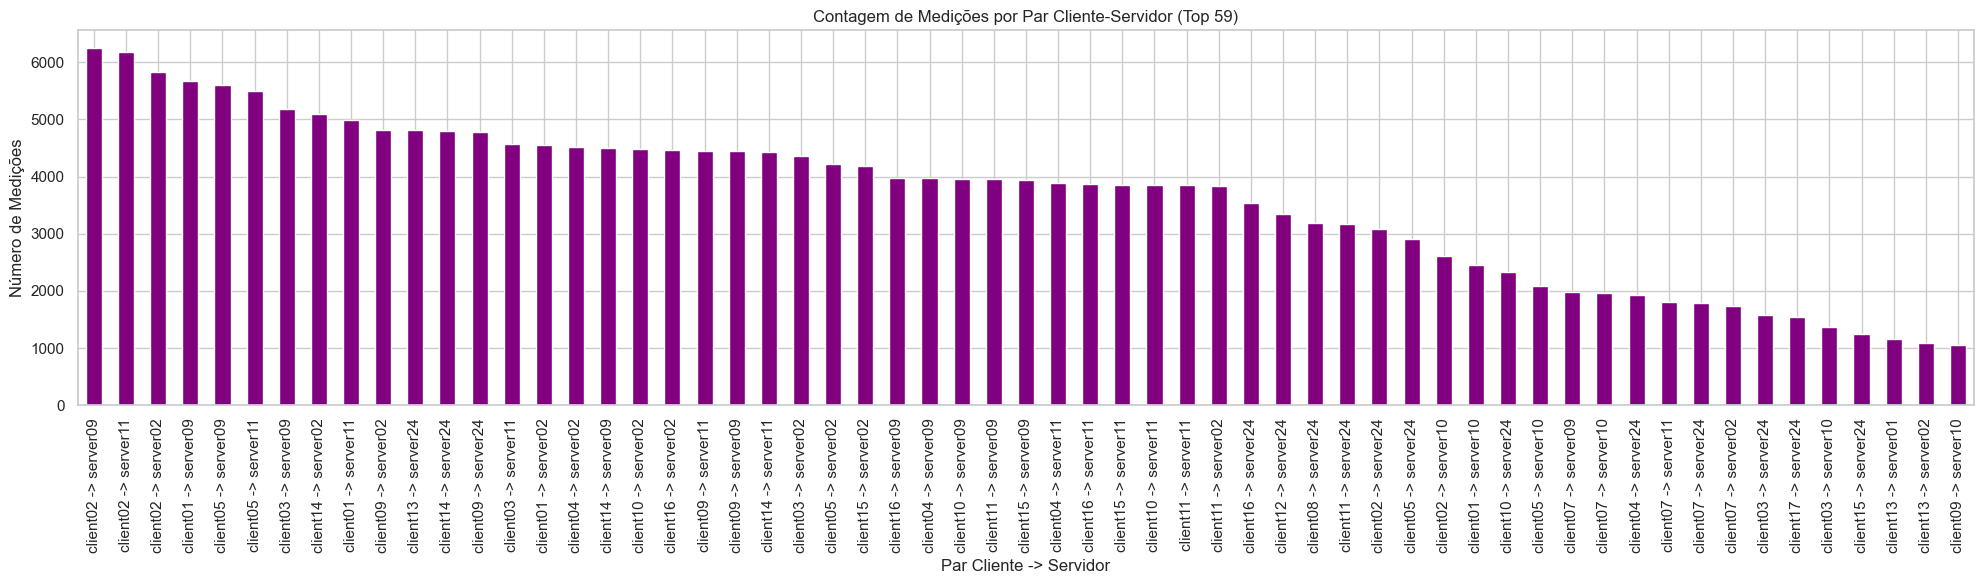

In [18]:
# Contagens Gerais
total_medicoes = len(df_clean)
num_clientes = df_clean['client_name'].nunique()
num_servidores = df_clean['server_name'].nunique()
num_pares = df_clean['client_server_pair'].nunique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")

num_pares = df_clean['client_server_pair'].nunique()
print(f"Total de pares cliente-servidor distintos: {num_pares}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df_clean['client_name'].value_counts()
medicoes_por_servidor = df_clean['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

medicoes_por_par = df_clean['client_server_pair'].value_counts()

# filtrar pelos 30 pares mais comuns
medicoes_por_par = medicoes_por_par.head(100)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
medicoes_por_par.plot(kind='bar', color='purple')
plt.title(f'Contagem de Medições por Par Cliente-Servidor (Top {len(medicoes_por_par)})')
plt.xlabel('Par Cliente -> Servidor')
plt.ylabel('Número de Medições')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
# Identificação das duplicatas
duplicatas = df_clean.duplicated(subset=['client_server_pair', 'timestamp'], keep=False)
df_duplicadas = df_clean[duplicatas].sort_values(by=['client_server_pair', 'timestamp']).dropna()
uuids_duplicados = df_duplicadas['test_uuid'].unique()

# Agregação e resumo
pares_com_duplicatas = df_duplicadas.groupby('client_server_pair').size()
nomes_pares = pares_com_duplicatas[pares_com_duplicatas > 1].index.tolist()

# 5. Print organizado (Refinado conforme seu pedido)
print("="*60)
print(f"RESUMO DE DUPLICATAS")
print("="*60)
print(f"Total de pares com registros colidindo: {len(pares_com_duplicatas)}")
print(f"Total absoluto de linhas duplicadas:    {len(df_duplicadas)}")
print(f"Total de UUIDs únicos colidindo:        {len(uuids_duplicados)}")

print("="*60)

RESUMO DE DUPLICATAS
Total de pares com registros colidindo: 0
Total absoluto de linhas duplicadas:    0
Total de UUIDs únicos colidindo:        0


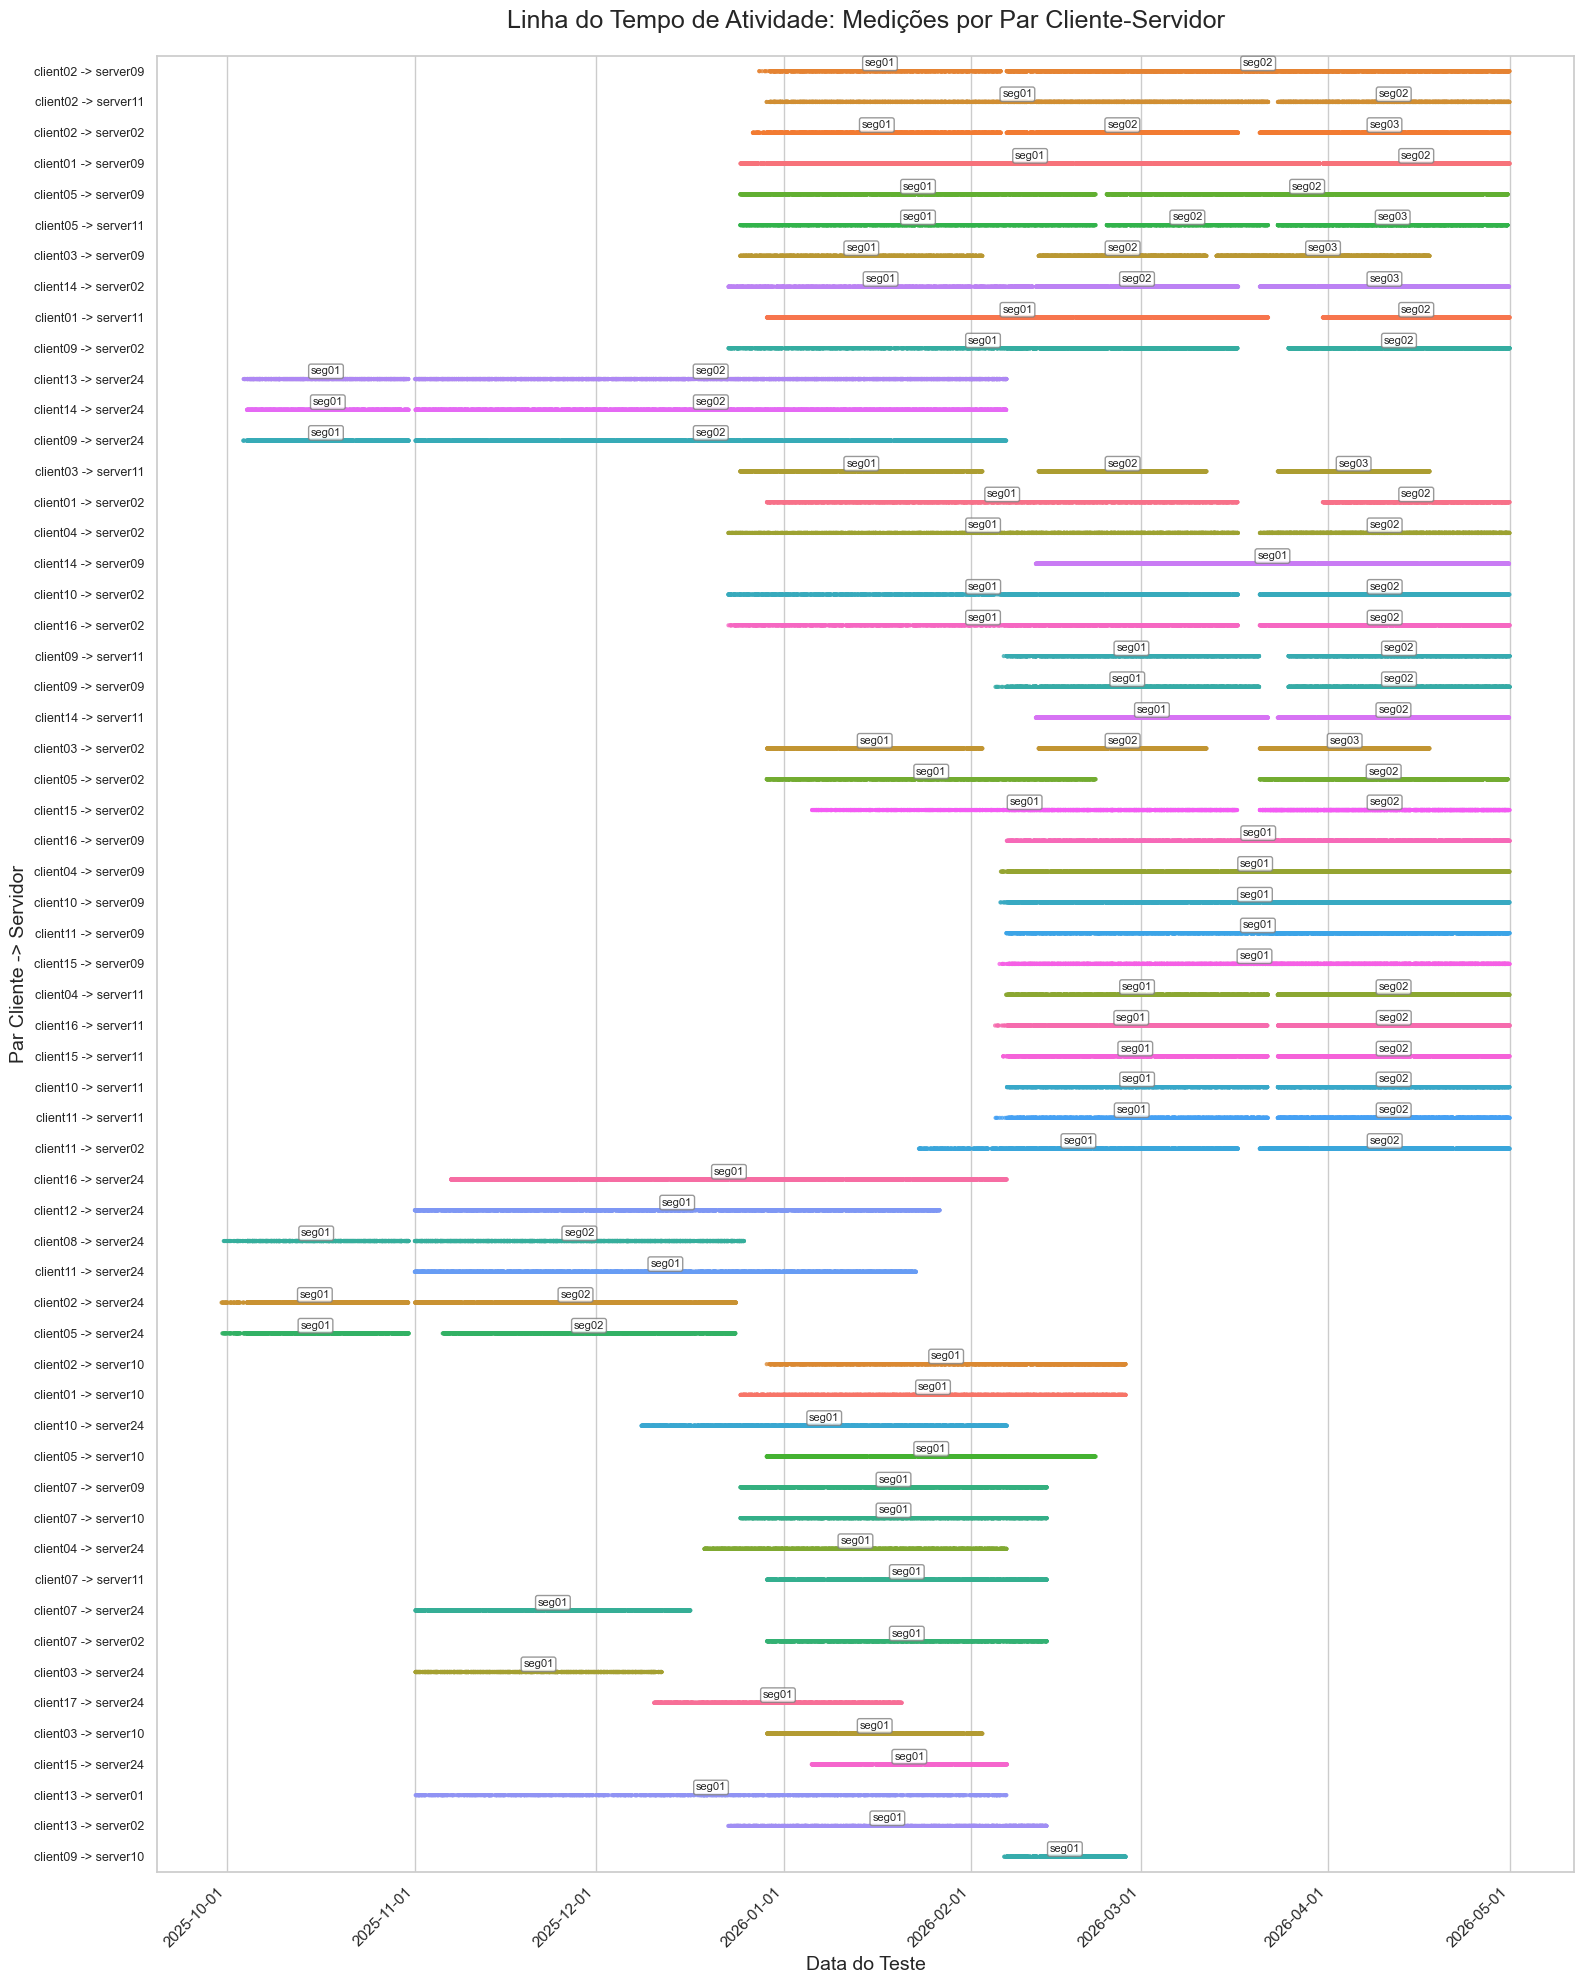

In [ ]:
# 1. Cria a lista com os PARES ordenados pelo volume de uso
ordem_pares = df_clean['client_server_pair'].value_counts().index

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 20))

sns.stripplot(
    data=df_clean,
    x='timestamp', 
    y='client_server_pair',
    hue='client_server_pair',
    palette="husl",
    size=3,
    alpha=0.8,
    legend=False,
    order=ordem_pares,
    jitter=False,
    zorder=2
)

# --- ADIÇÃO DAS CAIXAS DE TEXTO PARA OS SEGMENTOS ---

# Mapeia cada par para sua posição numérica no eixo Y (0, 1, 2...) baseada na ordem do plot
y_mapping = {par: i for i, par in enumerate(ordem_pares)}

# Agrupa por par e por bloco
for (par, bloco), group in df_clean.groupby(['client_server_pair', 'id_bloco']):
    
    # Encontra o meio do segmento no eixo X (data/hora)
    x_min = group['timestamp'].min()
    x_max = group['timestamp'].max()
    x_center = x_min + (x_max - x_min) / 2
    
    # Pega a posição Y correspondente ao par
    y_pos = y_mapping[par]
    
    # Adiciona a caixa de texto
    plt.text(
        x=x_center, 
        y=y_pos - 0.25, # O -0.25 desloca a caixa um pouco para cima para não cobrir a linha
        s=f"seg{int(bloco):02d}", 
        fontsize=8,
        ha='center', # Centraliza o texto no eixo X
        va='center', # Centraliza o texto no eixo Y
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8), # Cria a caixa visual
        zorder=3
    )
# -----------------------------------------------------

plt.title('Linha do Tempo de Atividade: Medições por Par Cliente-Servidor', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

# Formatação do eixo X (Tempo)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=9) # Fonte menor para os nomes dos pares

plt.tight_layout()
plt.show()

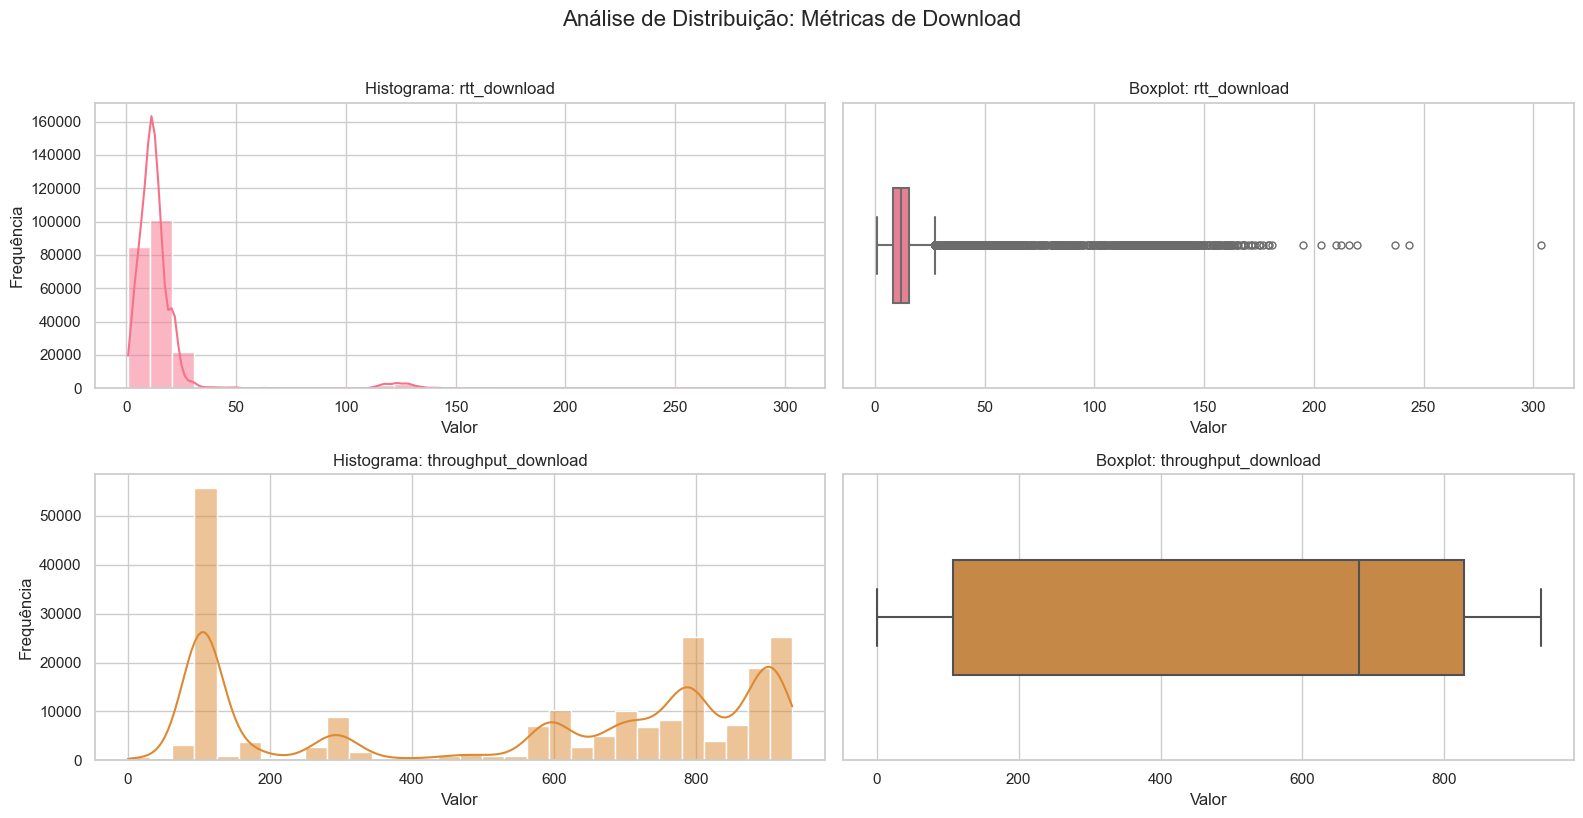

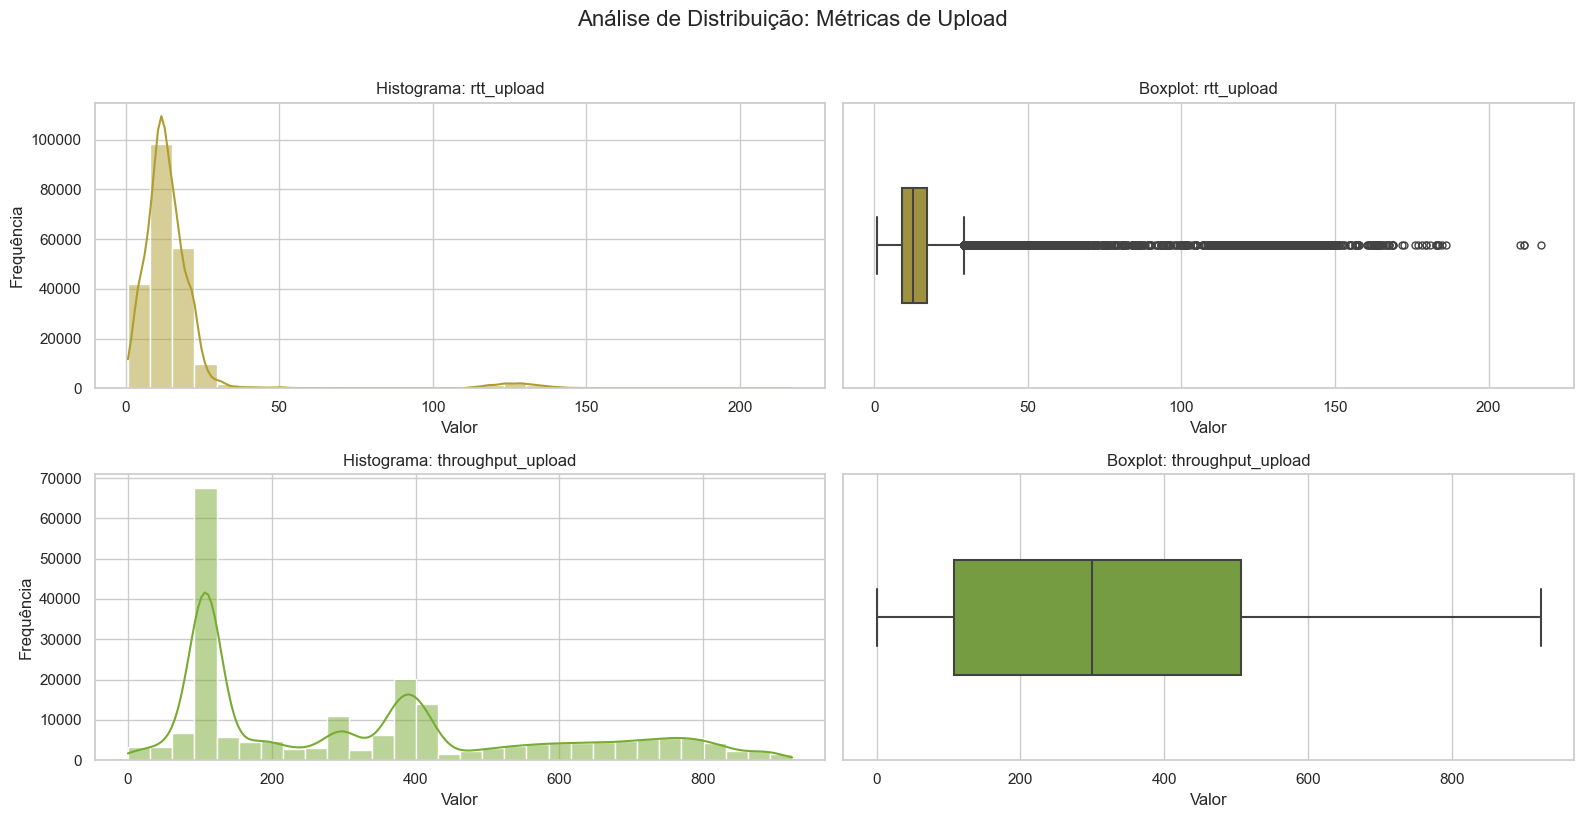

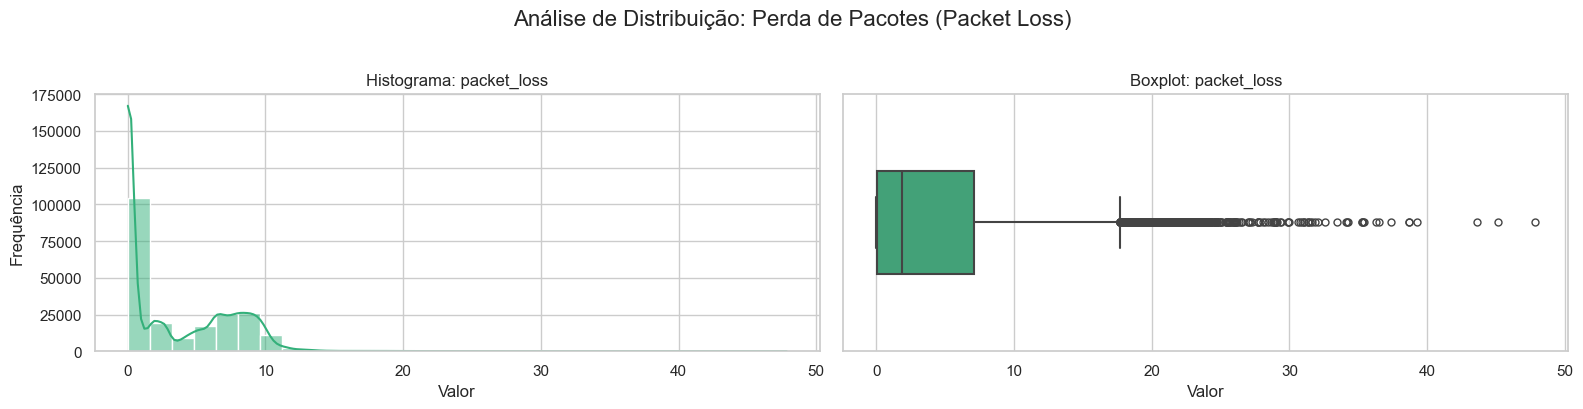

In [21]:
# Função auxiliar para gerar os gráficos padronizados por grupo sem tratamento interno
def plot_grupo_metricas(metrics, titulo, color_offset):
    metrics_exist = [m for m in metrics if m in df_clean.columns]
    if not metrics_exist:
        return
        
    fig, axes = plt.subplots(nrows=len(metrics_exist), ncols=2, figsize=(16, 4 * len(metrics_exist)))
    palette = sns.color_palette("husl", 10)
    
    for i, col in enumerate(metrics_exist):
        # Tratar a indexação dos axes (se for só 1 linha, axes é 1D)
        if len(metrics_exist) == 1:
            ax_hist = axes[0]
            ax_box = axes[1]
        else:
            ax_hist = axes[i, 0]
            ax_box = axes[i, 1]
            
        color = palette[color_offset + i]
        
        # Histograma com KDE (direto da coluna, sem dropna)
        sns.histplot(df_clean[col], kde=True, color=color, ax=ax_hist, bins=30)
        ax_hist.set_title(f'Histograma: {col}')
        ax_hist.set_xlabel('Valor')
        ax_hist.set_ylabel('Frequência')
        
        # Boxplot (direto da coluna, sem dropna)
        sns.boxplot(
            x=df_clean[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5,
            ax=ax_box
        )
        ax_box.set_title(f'Boxplot: {col}')
        ax_box.set_xlabel('Valor')

    plt.suptitle(titulo, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 1. Figura Exclusiva para Download
plot_grupo_metricas(
    ['rtt_download', 'throughput_download'], 
    'Análise de Distribuição: Métricas de Download', 
    color_offset=0
)

# 2. Figura Exclusiva para Upload
plot_grupo_metricas(
    ['rtt_upload', 'throughput_upload'], 
    'Análise de Distribuição: Métricas de Upload', 
    color_offset=2
)

# 3. Figura Exclusiva para Packet Loss
plot_grupo_metricas(
    ['packet_loss'], 
    'Análise de Distribuição: Perda de Pacotes (Packet Loss)', 
    color_offset=4
)